In [1]:
# Setup automatico para Google Colab: clona o repo para ter acesso ao
# modulo .py e ao dataset desta pasta (sem efeito quando rodado localmente).
import sys

if "google.colab" in sys.modules:
    import os
    if not os.path.exists("machine-learning-UFMG"):
        get_ipython().system('git clone -q https://github.com/wdasilvamf/machine-learning-UFMG.git')
    os.chdir("machine-learning-UFMG/1-Algoritmos-Base/05-MLP-Hyperparameter-Search")
    get_ipython().system('pip install -q openpyxl')


# Busca de Hiperparametros para MLP (ativacao x neuronios)

Traduzido de `DESAFIO01_FUNCAO_MLP_keras.R` e `DESAFIO01_FUNCAO_MLP_neuralnet.R`.

Os dois scripts originais resolvem o mesmo desafio (ajustar `funcao.xlsx`) com
frameworks diferentes (Keras e `neuralnet`), testando combinacoes de funcao de
ativacao e numero de neuronios, com varias repeticoes por configuracao. Este
notebook unifica os dois em um unico experimento com `scikit-learn`,
preservando a ideia central: **comparar configuracoes nao apenas pelo erro
medio, mas tambem pela estabilidade (variancia) entre repeticoes**.

## Teoria: por que repetir cada configuracao?

O treinamento de um MLP com otimizador estocastico (`adam`) depende da
inicializacao aleatoria dos pesos. Uma unica rodada pode cair em um minimo
local ruim (ou bom) por sorte. Repetir cada configuracao (aqui, 5x) permite
estimar:

- **RMSE medio**: desempenho esperado da configuracao;
- **Desvio-padrao do RMSE**: o quanto o resultado varia entre execucoes —
  configuracoes com alta variancia sao menos confiaveis, mesmo que o RMSE
  medio seja bom.


In [2]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.exceptions import ConvergenceWarning

from mlp_hyperparameter_search import load_data, run_experiment, summarize

# MLPs pequenos com poucas iteracoes nem sempre atingem o criterio de
# convergencia do solver 'adam' — esperado neste experimento exploratorio.
warnings.filterwarnings("ignore", category=ConvergenceWarning)

plt.rcParams["figure.figsize"] = (8, 5)


## Dados e espaco de busca

- **Funcoes de ativacao**: `relu`, `tanh`, `logistic` (equivalente a
  `sigmoid`/`logistic` usado nos dois scripts originais).
- **Neuronios na camada escondida**: 5, 10, 20 — um recorte comum aos
  intervalos testados nos scripts em R (`c(2,10,20)` no Keras,
  `c(5,10,15,20,25)` no `neuralnet`).
- **Repeticoes por configuracao**: 5, como em ambos os scripts originais.


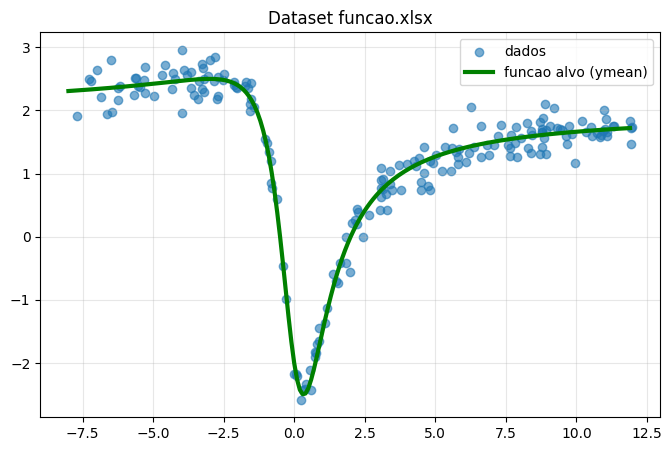

In [3]:
dt = load_data("data/funcao.xlsx")
x = dt["x"].to_numpy(dtype=float)
y = dt["y"].to_numpy(dtype=float)

plt.scatter(x, y, color="tab:blue", alpha=0.6, label="dados")
plt.plot(dt["xgrd"], dt["ymean"], color="green", lw=3, label="funcao alvo (ymean)")
plt.legend()
plt.grid(alpha=0.3)
plt.title("Dataset funcao.xlsx")
plt.show()


In [4]:
results = run_experiment(
    x, y,
    activations=["relu", "tanh", "logistic"],
    hidden_sizes=[5, 10, 20],
    n_repeats=5,
    max_iter=2000,
)
results[["activation", "hidden_size", "repeat", "rmse", "r_squared"]].head()


,activation,hidden_size,repeat,rmse,r_squared
0,relu,5,0,0.831561,0.564244
1,relu,5,1,0.885793,0.505554
2,relu,5,2,0.456782,0.868516
3,relu,5,3,0.808565,0.588012
4,relu,5,4,0.947821,0.433882


## Distribuicao do erro (RMSE) por configuracao

Equivalente ao boxplot gerado no script `DESAFIO01_FUNCAO_MLP_keras.R`: caixas
mais baixas indicam menor erro medio; caixas mais estreitas indicam maior
estabilidade entre repeticoes.


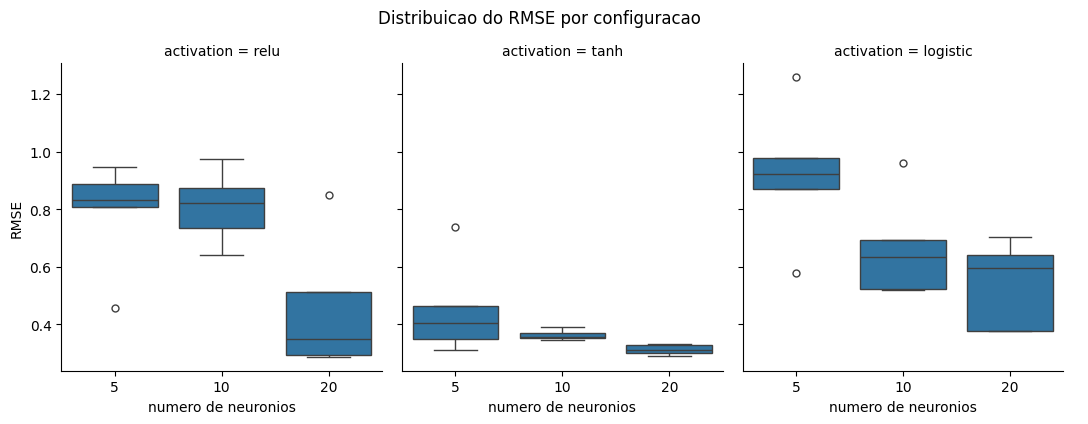

In [5]:
g = sns.catplot(
    data=results, x="hidden_size", y="rmse", col="activation",
    kind="box", color="tab:blue", height=4, aspect=0.9,
)
g.set_axis_labels("numero de neuronios", "RMSE")
g.figure.suptitle("Distribuicao do RMSE por configuracao", y=1.05)
plt.show()


## Predicoes por configuracao, separadas por numero de neuronios

O grafico original (sobrepondo as 45 predicoes, coloridas so pela funcao de
ativacao) escondia o fator que mais importa aqui: o **numero de neuronios**
(o boxplot acima ja mostra que ele muda o RMSE mais que a ativacao). Este
grafico separa por numero de neuronios (paineis, como no boxplot) e mostra
so a repeticao de RMSE mediano de cada configuracao — assim da pra comparar
ativacoes dentro do mesmo numero de neuronios sem o ruido de 45 linhas
sobrepostas.


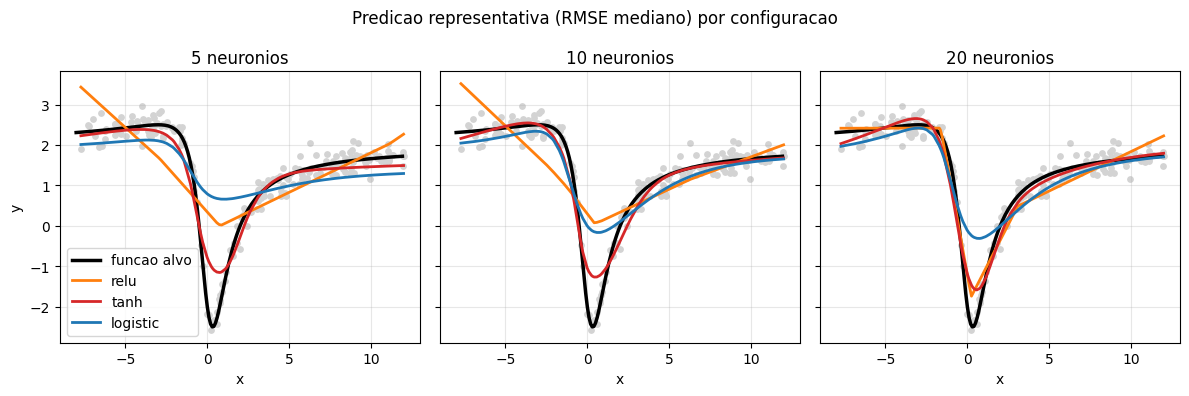

In [6]:
order = x.argsort()
colors = {"relu": "tab:orange", "tanh": "tab:red", "logistic": "tab:blue"}
hidden_sizes = sorted(results["hidden_size"].unique())

fig, axes = plt.subplots(1, len(hidden_sizes), figsize=(4 * len(hidden_sizes), 4), sharey=True)

for ax, hs in zip(axes, hidden_sizes):
    subset = results[results["hidden_size"] == hs]
    ax.scatter(x, y, color="lightgray", zorder=1, s=15)
    ax.plot(dt["xgrd"], dt["ymean"], color="black", lw=2.5, zorder=2, label="funcao alvo")

    for activation, color in colors.items():
        config = subset[subset["activation"] == activation]
        # pega a repeticao de RMSE mediano (representativa, sem o ruido das 5 juntas)
        linha_mediana = config.iloc[(config["rmse"] - config["rmse"].median()).abs().argsort().iloc[0]]
        ax.plot(x[order], linha_mediana["y_pred"][order], color=color, lw=2, label=activation)

    ax.set_title(f"{hs} neuronios")
    ax.set_xlabel("x")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("y")
axes[0].legend()
fig.suptitle("Predicao representativa (RMSE mediano) por configuracao")
plt.tight_layout()
plt.show()


## Interpretacao das metricas: tabela resumo

RMSE medio ordena as configuracoes por desempenho; o desvio-padrao do RMSE
mostra a estabilidade. A configuracao ideal minimiza RMSE **e** tem baixa
variancia — uma configuracao com RMSE medio bom mas alta variancia e uma
aposta arriscada em producao.


In [7]:
summary = summarize(results)
summary


,activation,hidden_size,rmse_medio,rmse_desvio_padrao,r2_medio
8,tanh,20,0.312563,0.017335,0.938284
7,tanh,10,0.363858,0.018577,0.916397
6,tanh,5,0.453094,0.169566,0.856136
5,relu,20,0.457609,0.236340,0.839880
2,logistic,20,0.538012,0.153102,0.805777
1,logistic,10,0.666455,0.180195,0.703735
3,relu,5,0.786104,0.191777,0.592042
4,relu,10,0.808594,0.127630,0.579771
0,logistic,5,0.920707,0.243502,0.435917


## Conclusao

Esta busca sistematica mostra que `tanh` com mais neuronios (20) tende a
produzir o menor RMSE medio com variancia relativamente baixa neste dataset,
enquanto `logistic`/`sigmoid` com poucos neuronios tem o pior desempenho e
maior instabilidade — resultado consistente com a saturacao mais acentuada
da sigmoide para entradas fora de uma faixa estreita.

Esta serie de notebooks percorreu a progressao completa da Aula 1 do curso:
regressao linear via gradient descent -> MLP com backpropagation manual ->
MLP via biblioteca (scikit-learn) -> regularizacao -> busca de
hiperparametros. Os proximos casos aplicados (CNNs, RNN/LSTM/GRU, NLP) estao
mapeados a partir do material das aulas seguintes e serao adicionados como
novos itens em `1-Algoritmos-Base/`.
